In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [3]:
train_df = pd.read_csv("../artifacts/train.csv")
test_df = pd.read_csv("../artifacts/test.csv")

print(train_df.shape)
print(test_df.shape)

(5634, 33)
(1409, 33)


In [4]:
train_df["Total Charges"] = pd.to_numeric(
    train_df["Total Charges"],
    errors="coerce"
)

test_df["Total Charges"] = pd.to_numeric(
    test_df["Total Charges"],
    errors="coerce"
)

In [5]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

target = "Churn Label"

X_train = train_df.drop(columns=drop_columns + [target])

y_train = train_df[target].map({"Yes": 1, "No": 0})

X_test = test_df.drop(columns=drop_columns + [target])

y_test = test_df[target].map({"Yes": 1, "No": 0})

In [6]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [7]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42)
}

results = []

best_model = None
best_score = 0
best_model_name = ""

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    if accuracy > best_score:
        best_score = accuracy
        best_model = model
        best_model_name = name

In [9]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.804826,0.651376,0.569519,0.607703
1,Logistic Regression,0.801987,0.643505,0.569519,0.604255
2,Gradient Boosting,0.798439,0.646104,0.532086,0.583578
3,Random Forest,0.784954,0.616393,0.502674,0.553756
4,Extra Trees,0.771469,0.581761,0.494652,0.534682
5,Decision Tree,0.735273,0.501266,0.529412,0.514954


In [10]:
param_grid = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 5]
    },

    "AdaBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 1]
    },

    "Extra Trees": {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5]
    }

}

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

best_model = None
best_accuracy = 0

for name, model in models.items():

    print("="*60)
    print(f"Tuning {name}")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_estimator = grid.best_estimator_

    prediction = best_estimator.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)

    print("Best Parameters :", grid.best_params_)
    print("Accuracy :", accuracy)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        grid.best_params_
    ])

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = best_estimator

Tuning Logistic Regression
Best Parameters : {'C': 10, 'solver': 'liblinear'}
Accuracy : 0.7970191625266146
Tuning Decision Tree
Best Parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Accuracy : 0.7913413768630234
Tuning Random Forest
Best Parameters : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy : 0.8062455642299503
Tuning Gradient Boosting
Best Parameters : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Accuracy : 0.7984386089425124
Tuning AdaBoost
Best Parameters : {'learning_rate': 1, 'n_estimators': 100}
Accuracy : 0.8062455642299503
Tuning Extra Trees
Best Parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy : 0.7977288857345636


In [12]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Best Parameters"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Best Parameters
0,AdaBoost,0.806246,0.650746,0.582888,0.614951,"{'learning_rate': 1, 'n_estimators': 100}"
1,Random Forest,0.806246,0.662379,0.550802,0.601460,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."
2,Gradient Boosting,0.798439,0.646104,0.532086,0.583578,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
3,Extra Trees,0.797729,0.636923,0.553476,0.592275,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
4,Logistic Regression,0.797019,0.630952,0.566845,0.597183,"{'C': 10, 'solver': 'liblinear'}"
5,Decision Tree,0.791341,0.608108,0.601604,0.604839,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."


In [13]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [14]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    learning_rate=1,
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

ada_prob = ada_model.predict_proba(X_test)[:,1]

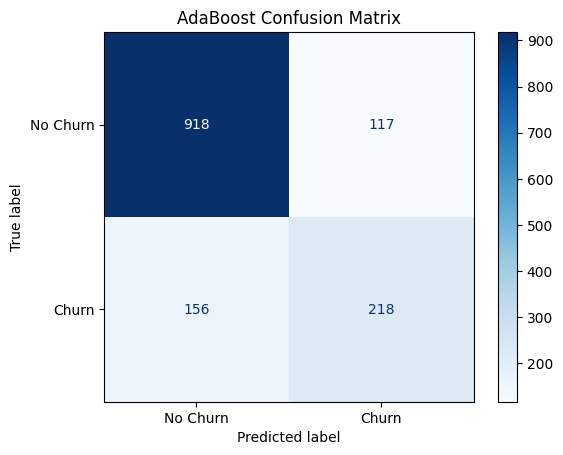

In [15]:
cm = confusion_matrix(y_test, ada_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn","Churn"]
)

disp.plot(cmap="Blues")

plt.title("AdaBoost Confusion Matrix")

plt.show()

In [16]:
ada_auc = roc_auc_score(y_test, ada_prob)

print("AdaBoost ROC-AUC Score :", round(ada_auc,4))

AdaBoost ROC-AUC Score : 0.8531


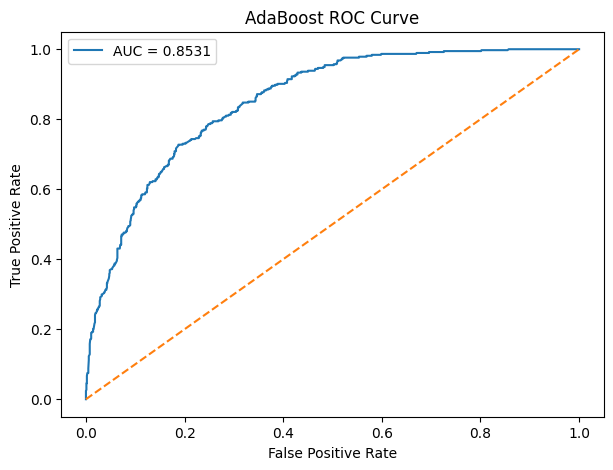

In [17]:
fpr, tpr, threshold = roc_curve(y_test, ada_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {ada_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("AdaBoost ROC Curve")

plt.legend()

plt.show()

## Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    max_depth=10,

    min_samples_leaf=2,

    min_samples_split=2,

    n_estimators=200,

    random_state=42
)

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

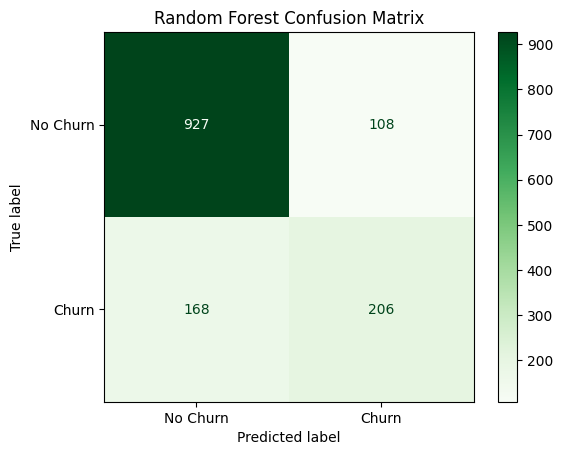

In [19]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["No Churn","Churn"]

)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [20]:
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC Score :", round(rf_auc,4))

Random Forest ROC-AUC Score : 0.8525


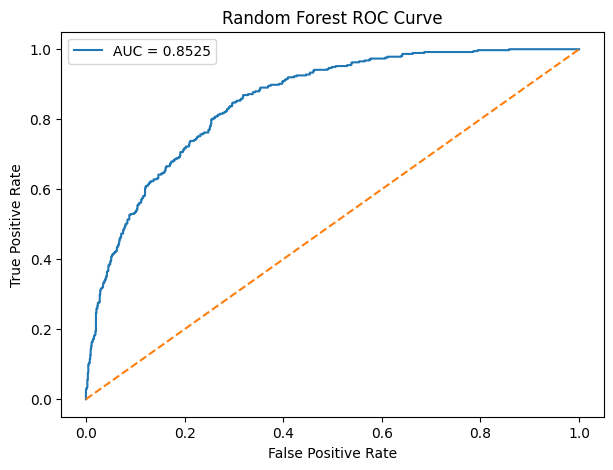

In [21]:
fpr, tpr, threshold = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f"AUC = {rf_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [22]:
comparison = pd.DataFrame({

    "Model":[

        "AdaBoost",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy_score(y_test,ada_pred),

        accuracy_score(y_test,rf_pred)

    ],

    "ROC-AUC":[

        ada_auc,

        rf_auc

    ]

})

comparison

,Model,Accuracy,ROC-AUC
0,AdaBoost,0.806246,0.853130
1,Random Forest,0.804116,0.852536


In [23]:
import joblib

joblib.dump(best_model, "../artifacts/model.pkl")
joblib.dump(preprocessor, "../artifacts/preprocessor.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
